<a href="https://colab.research.google.com/github/Divij6/MachineLearningPractice/blob/main/MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multiple Linear Regression


In [15]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

In [27]:
X_train = np.array([[2104,5,1,45], [1416,3,2,40], [852,2,1,35]])
y_train = np.array([460, 232, 178])
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [32]:
def compute_cost(X,y,w,b):
  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    f_wb = np.dot(X[i], w) + b
    cost = cost + (f_wb - y[i])**2
  cost = cost / (2*m)
  return cost

In [33]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [34]:
def compute_gradient(X,y,w,b):
  m , n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0
  for i in range(m):
    err = (np.dot(X[i],w)+b) - y[i]
    for j in range(n):
      dj_dw[j] = dj_dw[j] + err * X[i,j]
    dj_db = dj_db + err
  dj_dw = dj_dw / m
  dj_db = dj_db / m
  return dj_dw, dj_db

In [35]:
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: [-2.72623577e-03 -6.27197263e-06 -2.21745578e-06 -6.92403391e-05]
dj_dw at initial w,b: 
 -1.6739251501955248e-06


In [40]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
  J_history = []
  w = copy.deepcopy(w_in)
  b = b_in
  for i in range(num_iters):
    dj_dw, dj_db = gradient_function(X,y,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 100000:
      J_history.append(cost_function(X,y,w,b))
  return w,b,J_history

<a name="toc_15456_2"></a>
# 2 Problem Statement

You will use the motivating example of housing price prediction. The training dataset contains three examples with four features (size, bedrooms, floors and, age) shown in the table below.  Note that, unlike the earlier labs, size is in sqft rather than 1000 sqft. This causes an issue, which you will solve in the next lab!

| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  

You will build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  

Please run the following code cell to create your `X_train` and `y_train` variables.

In [41]:
X_train = np.array([[2104,5,1,45], [1416,3,2,40], [852,2,1,35]])
y_train = np.array([460, 232, 178])

In [64]:
w_ini = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
w_init = np.zeros_like(w_ini)
b_ini = 0.
iterations = 1000
alpha = 0.000000005
w_final , b_final , J_hist = gradient_descent(X_train,y_train,w_init,b_ini,compute_cost,compute_gradient,alpha,iterations)


In [65]:
m = X_train.shape[0]
for i in range(m):
  print(f"prediction: {np.dot(X_train[i],w_final) + b_final:0.2f}, target value: {y_train[i]}")

prediction: 425.59, target value: 460
prediction: 286.47, target value: 232
prediction: 172.42, target value: 178


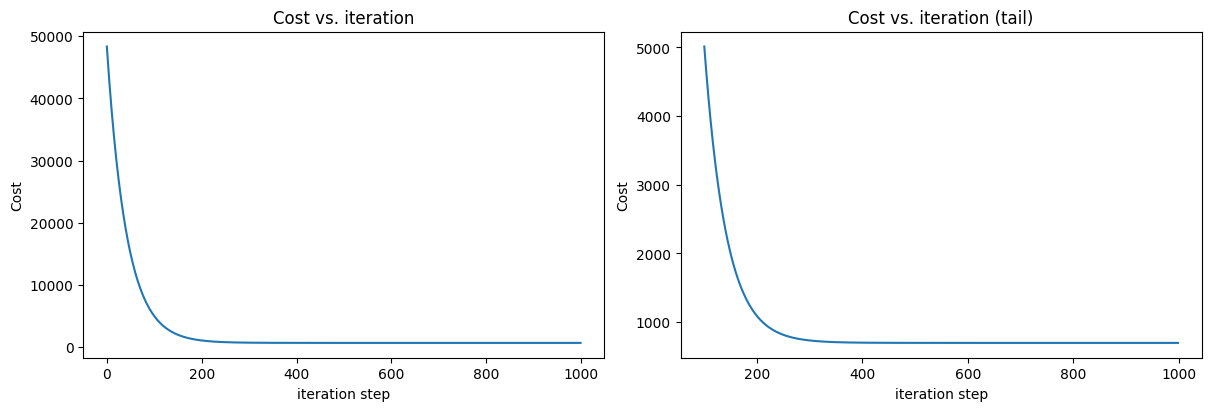

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')
plt.show()

Normalization of X_train


In [67]:
mu = np.mean(X_train,axis=0)
sigma = np.std(X_train,axis=0)
X_norm = (X_train - mu) / sigma

In [75]:
w_init = np.zeros_like(w_ini)
b_ini = 0.
iterations = 1000
alpha = 0.1
w_norm , b_norm , J_hist_norm = gradient_descent(X_norm,y_train,w_init,b_ini,compute_cost,compute_gradient,alpha,iterations)

In [76]:
m = X_train.shape[0]
for i in range(m):
  print(f"prediction: {np.dot(X_norm[i],w_norm) + b_norm:0.2f}, target value: {y_train[i]}")

prediction: 460.00, target value: 460
prediction: 232.00, target value: 232
prediction: 178.00, target value: 178


Predictions are perfect after normalization

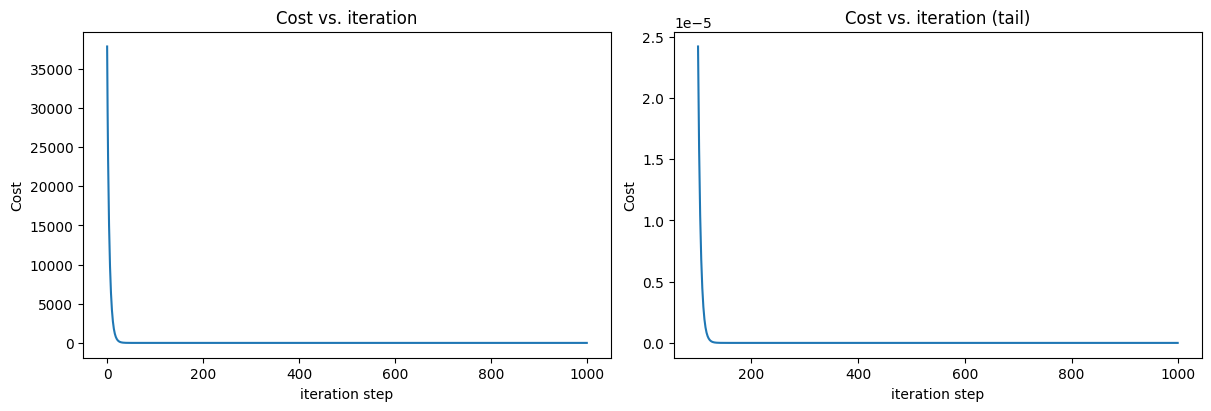

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist_norm)
ax2.plot(100 + np.arange(len(J_hist_norm[100:])), J_hist_norm[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')
plt.show()